In [11]:
using LinearAlgebra, DifferentialEquations, Plots, Printf

# ------------------------------------------------------------------------
# 1. Element‑level matrices (unchanged)
# ------------------------------------------------------------------------
function beam_element_stiffness(E, I, Le)
    c = E * I / Le^3
    return c * [
         12    6Le   -12   6Le;
         6Le   4Le^2 -6Le  2Le^2;
        -12   -6Le   12   -6Le;
         6Le   2Le^2 -6Le  4Le^2
    ]
end

function beam_element_mass(ρ, A, Le)
    c = ρ * A * Le / 420
    return c * [
        156    22Le    54    -13Le;
        22Le   4Le^2   13Le  -3Le^2;
        54     13Le    156   -22Le;
       -13Le  -3Le^2  -22Le   4Le^2
    ]
end

function assemble_beam(n_elem, E, I, ρ, A, L_total)
    n_nodes = n_elem + 1
    n_dof   = 2 * n_nodes
    Le      = L_total / n_elem
    Kb = zeros(n_dof, n_dof)
    Mb = zeros(n_dof, n_dof)
    for e in 1:n_elem
        ke = beam_element_stiffness(E, I, Le)
        me = beam_element_mass(ρ, A, Le)
        # CORRECTED indexing (explicit multiplication)
        dofs = [2*e-1, 2*e, 2*e+1, 2*e+2]
        Kb[dofs, dofs] .+= ke
        Mb[dofs, dofs] .+= me
    end
    return Kb, Mb, n_dof, n_nodes
end

# ------------------------------------------------------------------------
# 2. Chain matrices
# ------------------------------------------------------------------------
function chain_matrices(masses::Vector, springs::Vector)
    n = length(masses)
    @assert length(springs) == n+1 "Need n+1 springs for n masses"
    Mc = Diagonal(masses)
    Kc = zeros(n, n)
    for i in 1:n
        Kc[i, i] += springs[i] + springs[i+1]
        if i > 1
            Kc[i,   i-1] -= springs[i]
            Kc[i-1, i  ] -= springs[i]
        end
    end
    return Matrix(Mc), Kc
end

function selection_vector(beam_node::Int, n_beam_dof::Int)
    b = zeros(n_beam_dof)
    b[2*beam_node - 1] = 1.0
    return b
end

# ------------------------------------------------------------------------
# 3. Global assembly (beam + multiple chains)
# ------------------------------------------------------------------------
function assemble_global(Mb, Kb, chains, n_beam_dof)
    # Handle empty chains gracefully
    if isempty(chains)
        n_total = n_beam_dof
        return Mb, Kb
    end

    n_chain_dofs = [size(c.Mc,1) for c in chains]
    n_total = n_beam_dof + sum(n_chain_dofs; init=0)   # <-- add init=0

    M_global = zeros(n_total, n_total)
    K_global = zeros(n_total, n_total)

    M_global[1:n_beam_dof, 1:n_beam_dof] = Mb
    K_global[1:n_beam_dof, 1:n_beam_dof] = Kb

    offset = n_beam_dof
    for c in chains
        n_c = size(c.Mc, 1)
        b = selection_vector(c.node, n_beam_dof)
        ones_n = ones(n_c)
        Mc_tot = sum(diag(c.Mc); init=0.0)

        M_global[1:n_beam_dof, 1:n_beam_dof] .+= Mc_tot * (b * b')
        chain_range = offset+1 : offset+n_c
        M_global[1:n_beam_dof, chain_range] .+= b * (ones_n' * c.Mc)
        M_global[chain_range, 1:n_beam_dof] .+= c.Mc * ones_n * b'
        M_global[chain_range, chain_range] = c.Mc
        K_global[chain_range, chain_range] = c.Kc
        offset += n_c
    end
    return M_global, K_global
end

# ------------------------------------------------------------------------
# 4. Boundary condition helpers
# ------------------------------------------------------------------------
function fixed_free_dofs(n_nodes, n_beam_dof)
    fixed = [1, 2]          # fix w and θ at node 1
    return setdiff(1:n_beam_dof, fixed)
end

function simply_supported_dofs(n_nodes, n_beam_dof)
    fixed = [1, 2*n_nodes-1]
    return setdiff(1:n_beam_dof, fixed)
end

function clamped_clamped_dofs(n_nodes, n_beam_dof)
    fixed = [1, 2, 2*n_nodes-1, 2*n_nodes]
    return setdiff(1:n_beam_dof, fixed)
end

function apply_bcs(M_global, K_global, free_beam_dofs, n_beam_dof, n_total)
    chain_dofs = n_beam_dof+1 : n_total
    free_global = vcat(free_beam_dofs, collect(chain_dofs))
    return M_global[free_global, free_global], K_global[free_global, free_global], free_global
end

# ------------------------------------------------------------------------
# 5. Eigenvalue solver
# ------------------------------------------------------------------------
function solve_modes(M_free, K_free, n_modes::Int)
    vals, vecs = eigen(Symmetric(K_free), Symmetric(M_free))
    pos = findall(vals .> 1e-8)
    vals = vals[pos]
    vecs = vecs[:, pos]
    n_keep = min(n_modes, length(vals))
    ωn = sqrt.(vals[1:n_keep])
    fn = ωn ./ (2π)
    Φ  = vecs[:, 1:n_keep]
    return ωn, fn, Φ
end

# ------------------------------------------------------------------------
# 6. Modal time response for arbitrary forcing (numerical convolution)
# ------------------------------------------------------------------------
function modal_time_response(Φ, ωn, M_free, F_free_func, q0, qdot0, tspan, t_output)
    n_modes = length(ωn)
    n_dof   = size(Φ, 1)
    n_t     = length(t_output)

    η0 = Φ' * M_free * q0
    η̇0 = Φ' * M_free * qdot0

    q_full = zeros(n_dof, n_t)
    dt = t_output[2] - t_output[1]   # assume uniform

    for i in 1:n_modes
        ϕ = Φ[:, i]
        ω = ωn[i]

        # Modal force at output times
        f_modal = [ϕ' * F_free_func(t) for t in t_output]

        # Duhamel integral (trapezoidal)
        η = zeros(n_t)
        for j in 1:n_t
            integ = 0.0
            for k in 1:j-1
                τ = t_output[k]
                integ += f_modal[k] * sin(ω * (t_output[j] - τ))
            end
            if j > 1
                η[j] = (1/ω) * integ * dt
            end
        end

        # Add homogeneous part
        η .+= η0[i] * cos.(ω * t_output) .+ (η̇0[i] / ω) * sin.(ω * t_output)

        q_full .+= ϕ * η'
    end
    return q_full
end

# ------------------------------------------------------------------------
# 7. Main configurable simulation function
# ------------------------------------------------------------------------
"""
    simulate_beam(; beam_params, mesh, bc_type, chains, force_params, sim_params)

Simulate a Euler–Bernoulli beam with optional internal mass‑spring chains.

# Arguments (all keyword arguments with defaults)

## Beam properties
- `beam_params`: NamedTuple with `E`, `ρ`, `A`, `I` (or compute from `width`, `height`)
- `mesh`: NamedTuple with `L` (total length), `n_elem` (number of elements)

## Boundary conditions
- `bc_type`: `:cantilever`, `:simply_supported`, or `:clamped_clamped`

## Chains (empty vector `[]` for pure beam)
- `chains`: Vector of NamedTuples `(node, masses, springs)`
  Example: `[(node=3, masses=fill(0.05,10), springs=fill(500.0,11)), ...]`

## Forcing
- `force_params`: NamedTuple with:
  - `location_node` (beam node index where force is applied transversely)
  - `F0` (peak force in N)
  - `t_imp` (half‑sine impulse duration, s)
  - (For other force shapes, modify `F_free_func` inside the function.)

## Simulation settings
- `sim_params`: NamedTuple with:
  - `t_end` (simulation end time, s)
  - `n_t` (number of output time points)
  - `n_modes` (number of modes to retain)

Returns a NamedTuple containing:
- `t`: time vector
- `w_beam`: matrix of transverse displacements (nodes × time)
- `beam_nodes`: list of free beam nodes (rows of `w_beam`)
- `fn`: natural frequencies (Hz)
- `Φ`: mode shapes (free DOFs × modes)
- `M_global`, `K_global`: unconstrained matrices
- `free_global`: indices of free DOFs in global system
- `q_full`: full free‑DOF response (if needed for chains)
- `chain_responses`: dictionary mapping chain attachment node to absolute mass displacements (if chains exist)
"""
function simulate_beam(;
    beam_params = (E=210e9, ρ=7800.0, width=0.05, height=0.05),  # or provide A,I directly
    mesh = (L=1.0, n_elem=9),
    bc_type = :cantilever,
    chains = [],   # e.g., [(node=3, masses=[...], springs=[...])]
    force_params = (location_node=10, F0=100.0, t_imp=0.005),
    sim_params = (t_end=0.5, n_t=500, n_modes=12)
)

    # Unpack beam parameters
    E = beam_params.E
    ρ = beam_params.ρ
    if haskey(beam_params, :A) && haskey(beam_params, :I)
        A = beam_params.A
        I = beam_params.I
    else
        w = beam_params.width
        h = beam_params.height
        A = w * h
        I = w * h^3 / 12
    end

    L = mesh.L
    n_elem = mesh.n_elem
    n_nodes = n_elem + 1

    # Assemble beam matrices
    Kb, Mb, n_beam_dof, _ = assemble_beam(n_elem, E, I, ρ, A, L)

    # Build chain matrices
    chain_structs = []
    for c in chains
        Mc, Kc = chain_matrices(c.masses, c.springs)
        push!(chain_structs, (node=c.node, Mc=Mc, Kc=Kc))
    end

    # Global assembly (now safe with empty chains)
    M_global, K_global = assemble_global(Mb, Kb, chain_structs, n_beam_dof)
    n_total = size(M_global, 1)   # simpler than manual calculation

    # Boundary conditions
    free_beam = if bc_type == :cantilever
        fixed_free_dofs(n_nodes, n_beam_dof)
    elseif bc_type == :simply_supported
        simply_supported_dofs(n_nodes, n_beam_dof)
    elseif bc_type == :clamped_clamped
        clamped_clamped_dofs(n_nodes, n_beam_dof)
    else
        error("Unknown bc_type: $bc_type")
    end

    M_free, K_free, free_global = apply_bcs(M_global, K_global, free_beam, n_beam_dof, n_total)

    println("Total DOFs: $n_total  →  Free DOFs: $(length(free_global))")

    # Natural frequencies
    n_modes = min(sim_params.n_modes, length(free_global))
    ωn, fn, Φ = solve_modes(M_free, K_free, n_modes)

    println("\nFirst $n_modes natural frequencies (Hz):")
    for i in 1:n_modes
        @printf("  Mode %2d: %8.3f Hz\n", i, fn[i])
    end

    # External force function
    force_node_global = 2 * force_params.location_node - 1
    local_idx = findfirst(==(force_node_global), free_global)

    function F_free(t)
        F = zeros(length(free_global))
        if !isnothing(local_idx) && t <= force_params.t_imp
            F[local_idx] = force_params.F0 * sin(π * t / force_params.t_imp)
        end
        return F
    end

    # Modal time response
    t_plot = range(0.0, sim_params.t_end, length=sim_params.n_t)
    q0 = zeros(length(free_global))
    qdot0 = zeros(length(free_global))
    println("\nComputing modal response...")
    q_full = modal_time_response(Φ, ωn, M_free, F_free, q0, qdot0, (0.0, sim_params.t_end), t_plot)
    println("Done.")

    # Extract beam transverse displacements
    beam_w_indices = Int[]
    beam_nodes = Int[]
    for node in 1:n_nodes
        gdof = 2*node - 1
        idx = findfirst(==(gdof), free_global)
        if !isnothing(idx)
            push!(beam_w_indices, idx)
            push!(beam_nodes, node)
        end
    end
    w_beam = q_full[beam_w_indices, :]   # (n_free_nodes) × (n_t)

    # Extract chain responses (absolute displacements) for plotting
    chain_responses = Dict()
    offset = length(free_beam)   # number of free beam DOFs
    for c in chains
        n_masses = length(c.masses)
        chain_range = offset+1 : offset+n_masses
        v_rel = q_full[chain_range, :]   # relative displacements
        # Find beam node displacement
        node_idx = findfirst(==(c.node), beam_nodes)
        if !isnothing(node_idx)
            w_node = w_beam[node_idx:node_idx, :]
            u_abs = w_node .+ v_rel
            chain_responses[c.node] = u_abs
        end
        offset += n_masses
    end

    # # Simple plot (can be turned off or customized)
    # p1 = plot(t_plot, w_beam' * 1e3;
    #           label = reshape(["Node $n" for n in beam_nodes], 1, :),
    #           xlabel="Time (s)", ylabel="Displacement (mm)",
    #           title="Beam Transverse Response", legend=:topright)
    # display(p1)

    return (;
        t = t_plot,
        w_beam,
        beam_nodes,
        fn, Φ, ωn,
        M_global, K_global, free_global,
        q_full,
        chain_responses,
    )
end

simulate_beam

In [15]:
res = simulate_beam(
    beam_params = (E=210e9, ρ=7800.0, width=0.05, height=0.05),
    mesh = (L=1.0, n_elem=20),
    bc_type = :cantilever,
    chains = [],
    force_params = (location_node=10, F0=100.0, t_imp=0.005),
    sim_params = (t_end=0.5, n_t=500, n_modes=12)
)

Total DOFs: 42  →  Free DOFs: 40

First 12 natural frequencies (Hz):
  Mode  1:   41.910 Hz
  Mode  2:  262.643 Hz
  Mode  3:  735.418 Hz
  Mode  4: 1441.193 Hz
  Mode  5: 2382.650 Hz
  Mode  6: 3559.997 Hz
  Mode  7: 4973.960 Hz
  Mode  8: 6625.732 Hz
  Mode  9: 8517.141 Hz
  Mode 10: 10650.808 Hz
  Mode 11: 13030.293 Hz
  Mode 12: 15660.212 Hz

Computing modal response...
Done.


(t = 0.0:0.001002004008016032:0.5, w_beam = [0.0 0.0 … -2.0760202762885079e-7 -2.3049784813955152e-7; 0.0 0.0 … -7.274848551094542e-7 -9.458840143956465e-7; … ; 0.0 0.0 … -5.863998271176174e-5 -4.699807587982209e-5; 0.0 0.0 … -6.347142821062483e-5 -4.9508391638159e-5], beam_nodes = [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21], fn = [41.90951496884531, 262.6429838888467, 735.4184551389682, 1441.1930894885186, 2382.6501929047863, 3559.9971175080204, 4973.959787327384, 6625.731606269112, 8517.14066955463, 10650.807564938283, 13030.292872367896, 15660.211893308055], Φ = [-0.0019448855463278733 0.011480754455005956 … 0.2897529820201455 -0.3144401036965278; -0.07688212041590124 0.43935875599999386 … 5.474939726298506 -4.761431844074121; … ; -0.45291086224051014 -0.45291271173632675 … 0.4567572258952766 0.4582175362878457; -0.6234342860387517 -2.165275339419563 … 15.089062869742934 16.595683004608485], ωn = [263.32524868327175, 1650.2345374042063, 4620.770431957874

In [16]:
chains = [
    (node=3, masses=fill(0.0005, 1), springs=fill(1000000.0, 2)),
]

stiff = simulate_beam(
    beam_params = (E=210e9, ρ=7800.0, width=0.05, height=0.05),
    mesh = (L=1.0, n_elem=20),
    bc_type = :cantilever,
    chains = chains,
    force_params = (location_node=10, F0=100.0, t_imp=0.005),
    sim_params = (t_end=0.5, n_t=500, n_modes=12)   # more modes due to chain resonances
)



Total DOFs: 43  →  Free DOFs: 41

First 12 natural frequencies (Hz):
  Mode  1:   41.910 Hz
  Mode  2:  262.643 Hz
  Mode  3:  735.416 Hz
  Mode  4: 1441.182 Hz
  Mode  5: 2382.613 Hz
  Mode  6: 3559.906 Hz
  Mode  7: 4973.776 Hz
  Mode  8: 6625.389 Hz
  Mode  9: 8516.366 Hz
  Mode 10: 10066.308 Hz
  Mode 11: 10652.459 Hz
  Mode 12: 13030.483 Hz

Computing modal response...
Done.


(t = 0.0:0.001002004008016032:0.5, w_beam = [0.0 0.0 … -3.282242495210452e-7 -2.215607673334203e-7; 0.0 0.0 … -1.2359233870611807e-6 -1.215920897404028e-6; … ; 0.0 0.0 … -5.87668889444634e-5 -4.715800955449504e-5; 0.0 0.0 … -6.387014459858969e-5 -4.98693212172741e-5], beam_nodes = [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21], fn = [41.90951432539418, 262.642868252047, 735.416482766778, 1441.181901847236, 2382.6128063244378, 3559.905842297273, 4973.775778104514, 6625.388680662457, 8516.366434164129, 10066.308367974914, 10652.458754971827, 13030.483018081035], Φ = [0.0019448857142491398 0.011480782792872584 … -0.2606650654446702 -0.28983721962219877; 0.07688212616679534 0.43935969839963035 … -5.787897360451179 -5.476746637444329; … ; 0.6234342708252303 -2.1652737451682857 … 13.587712244340974 -15.088197531455576; 1.3169492372411634e-7 2.8581854764595658e-5 … 2.5464308616364506 0.49262774094936995], ωn = [263.32524464034907, 1650.2338108367653, 4620.75803917790

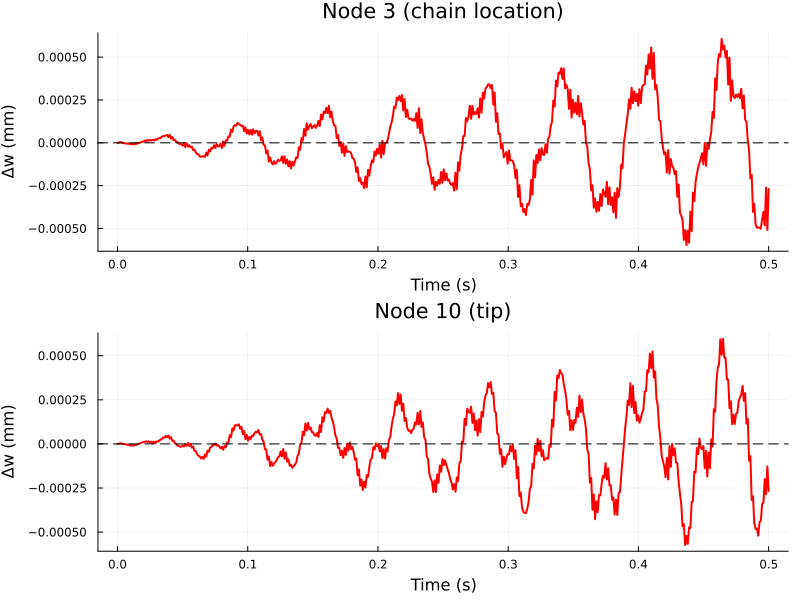

Difference plot saved → beam_chain_difference.png


In [17]:
# ----------------------------------------------------------------
# Plot difference between pure beam and beam with chain at node 3
# ----------------------------------------------------------------

# Time vector (same for both simulations)
t = res.t

# Nodes we want to compare
nodes_to_plot = [3, 10]   # chain location and tip

# Extract displacements for pure beam (res)
w_pure = res.w_beam
beam_nodes_pure = res.beam_nodes

# Extract displacements for coupled beam (stiff)
w_coupled = stiff.w_beam
beam_nodes_coupled = stiff.beam_nodes

# Create a figure with two subplots: one for node 3, one for node 10
p_diff = plot(layout=(2,1), size=(800,600),
              xlabel="Time (s)", ylabel="Δw (mm)",
              title=["Node 3 (chain location)" "Node 10 (tip)"],
              legend=false)

for (i, node) in enumerate(nodes_to_plot)
    # Find row index in each result
    idx_pure = findfirst(==(node), beam_nodes_pure)
    idx_coupled = findfirst(==(node), beam_nodes_coupled)
    
    if !isnothing(idx_pure) && !isnothing(idx_coupled)
        Δw = (w_coupled[idx_coupled, :] - w_pure[idx_pure, :]) * 1e3   # convert to mm
        plot!(p_diff[i], t, Δw, lw=2, color=:red)
        # Add zero line for reference
        hline!(p_diff[i], [0.0], lw=1, color=:black, linestyle=:dash)
    end
end

display(p_diff)
savefig(p_diff, "beam_chain_difference.png")
println("Difference plot saved → beam_chain_difference.png")